In [1]:
import pandas as pd
import matplotlib.pyplot as plt

enrolment = pd.read_csv("../data/enrolment_cleaned.csv")
demographic = pd.read_csv("../data/demographic_cleaned.csv")
biometric = pd.read_csv("../data/biometric_cleaned.csv")


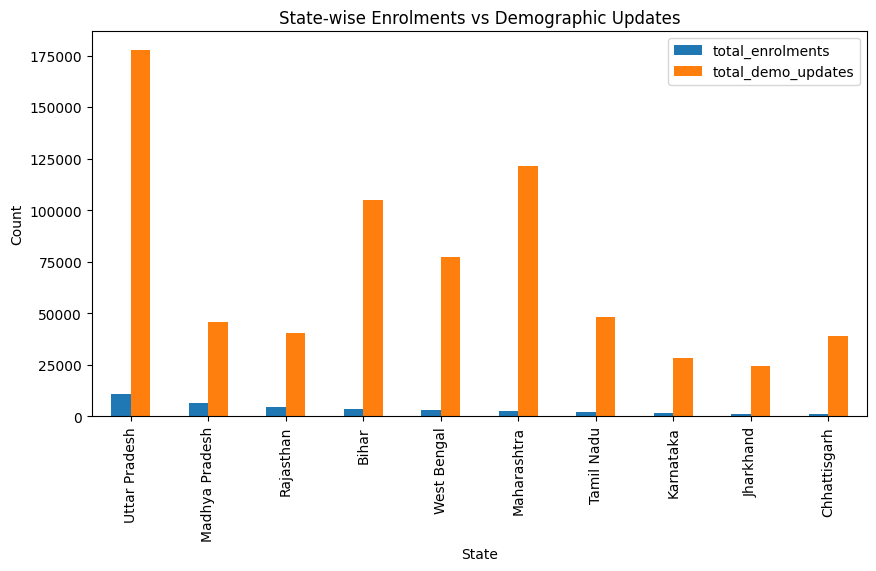

In [2]:
# Total enrolments per state
state_enrol = enrolment.groupby('state')[['age_0_5','age_5_17','age_18_greater']].sum()
state_enrol['total_enrolments'] = state_enrol.sum(axis=1)

# Total demographic updates per state
demo_cols = [col for col in demographic.columns if col.startswith('demo_')]
state_demo = demographic.groupby('state')[demo_cols].sum()
state_demo['total_demo_updates'] = state_demo.sum(axis=1)

# Combine
state_compare = state_enrol[['total_enrolments']].join(
    state_demo[['total_demo_updates']], how='inner'
)

# Plot (Top 10 states by enrolment)
top_states = state_compare.sort_values('total_enrolments', ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))
plt.title("State-wise Enrolments vs Demographic Updates")
plt.ylabel("Count")
plt.xlabel("State")
plt.show()


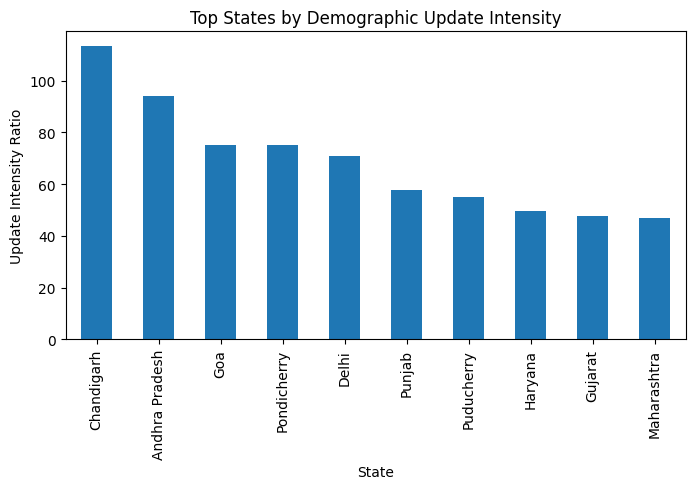

In [3]:
state_compare['update_intensity_ratio'] = (
    state_compare['total_demo_updates'] / state_compare['total_enrolments']
)

# Top 10 states by update intensity
state_compare.sort_values('update_intensity_ratio', ascending=False).head(10)[
    'update_intensity_ratio'
].plot(kind='bar', figsize=(8,4))

plt.title("Top States by Demographic Update Intensity")
plt.ylabel("Update Intensity Ratio")
plt.xlabel("State")
plt.show()


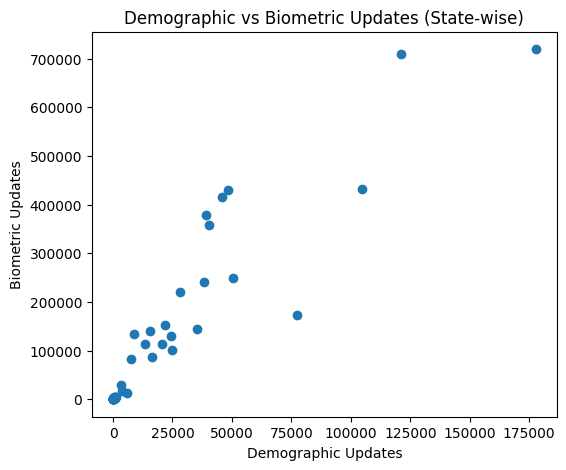

In [4]:
# Biometric updates per state
bio_cols = [col for col in biometric.columns if col.startswith('bio_')]
state_bio = biometric.groupby('state')[bio_cols].sum()
state_bio['total_bio_updates'] = state_bio.sum(axis=1)

# Combine with demographic updates
update_compare = state_demo[['total_demo_updates']].join(
    state_bio[['total_bio_updates']], how='inner'
)

# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(
    update_compare['total_demo_updates'],
    update_compare['total_bio_updates']
)
plt.xlabel("Demographic Updates")
plt.ylabel("Biometric Updates")
plt.title("Demographic vs Biometric Updates (State-wise)")
plt.show()
